In [1]:
import torch
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

In [2]:
c1 = "#E1000F"  # ETO
c2 = "#F37022"  # DOT
c3 = "#000091"  # IEO

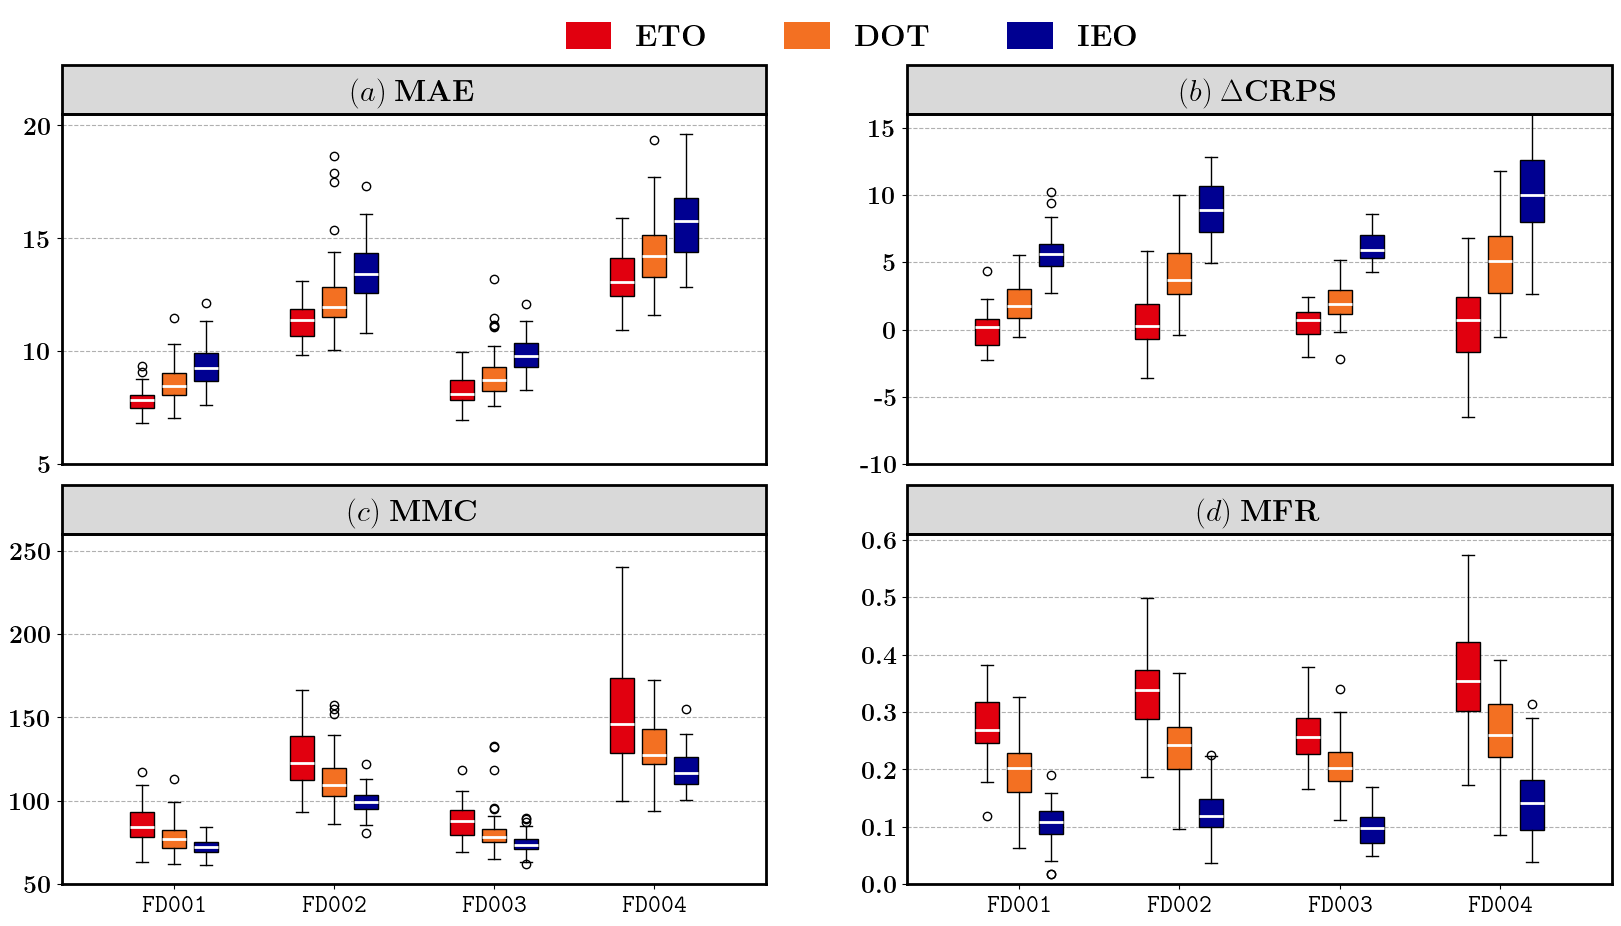

In [3]:
plt.rcParams["font.family"] = "CMU serif"
plt.rcParams["font.size"] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.usetex"] = True
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
ax1=axes[0,0]
ax2=axes[0,1]
ax3=axes[1,0]
ax4=axes[1,1]
# # ====================================================
name = ["FD001", "FD002", "FD003", "FD004"]
titles = ["$(a)\\;\\mathbf{MAE}$", "$(b)\\;\\Delta\\mathbf{CRPS}$", "$(c)\\;\\mathbf{MMC}$", "$(d)\\;\\mathbf{MFR}$"]
for i in range(4):
    data = torch.load("../results/%s_ratio=05.pth" % name[i])
    # ====================================================
    ax1.boxplot(data[:, 0, 0], positions=[i-0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c1}, medianprops={'color':'white', 'linewidth':2})
    ax1.boxplot(data[:, 1, 0], positions=[i+0.00], widths=0.15, patch_artist=True, boxprops={'facecolor':c2}, medianprops={'color':'white', 'linewidth':2})
    ax1.boxplot(data[:, 2, 0], positions=[i+0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c3}, medianprops={'color':'white', 'linewidth':2})
    # ====================================================
    ax2.boxplot(data[:, 0, 1] - data[:, 0, 2], positions=[i-0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c1}, medianprops={'color':'white', 'linewidth':2})
    ax2.boxplot(data[:, 1, 1] - data[:, 1, 2], positions=[i+0.00], widths=0.15, patch_artist=True, boxprops={'facecolor':c2}, medianprops={'color':'white', 'linewidth':2})
    ax2.boxplot(data[:, 2, 1] - data[:, 2, 2], positions=[i+0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c3}, medianprops={'color':'white', 'linewidth':2})
    # ====================================================
    ax3.boxplot(data[:, 0, 3], positions=[i-0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c1}, medianprops={'color':'white', 'linewidth':2})
    ax3.boxplot(data[:, 1, 3], positions=[i+0.00], widths=0.15, patch_artist=True, boxprops={'facecolor':c2}, medianprops={'color':'white', 'linewidth':2})
    ax3.boxplot(data[:, 2, 3], positions=[i+0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c3}, medianprops={'color':'white', 'linewidth':2})
    # ====================================================
    ax4.boxplot(data[:, 0, 5], positions=[i-0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c1}, medianprops={'color':'white', 'linewidth':2})
    ax4.boxplot(data[:, 1, 5], positions=[i+0.00], widths=0.15, patch_artist=True, boxprops={'facecolor':c2}, medianprops={'color':'white', 'linewidth':2})
    ax4.boxplot(data[:, 2, 5], positions=[i+0.20], widths=0.15, patch_artist=True, boxprops={'facecolor':c3}, medianprops={'color':'white', 'linewidth':2})
# ====================================================
for ax in [ax3, ax4]:
    ax.set_xticks([0, 1, 2, 3], [r"\texttt{%s}" % i for i in name])
    
ax1.set_xticks([])
ax2.set_xticks([])

ax1.grid(axis='y', ls='--')
ax2.grid(axis='y', ls='--')
ax3.grid(axis='y', ls='--')
ax4.grid(axis='y', ls='--')

ax1.set_yticks([5, 10, 15, 20], ["$\\textbf{%.0f}$" % i for i in [5, 10, 15, 20] ])
ax2.set_yticks([-10, -5, 0, 5, 10, 15], ["$\\textbf{%.0f}$" % i for i in [-10, -5, 0, 5, 10, 15]])
ax3.set_yticks([50, 100, 150, 200, 250], ["$\\textbf{%.0f}$" % i for i in [50, 100, 150, 200, 250] ])
ax4.set_yticks(torch.arange(0.0, 0.7, 0.1), ["$\\textbf{%0.1f}$" % i for i in torch.arange(0.0, 0.7, 0.1) ])

ax1.set_ylim([5, 20.5])
ax2.set_ylim([-10, 16])
ax3.set_ylim([50, 260])
ax4.set_ylim([0.0, 0.61])

legend_handles = [Patch(facecolor=c1, edgecolor='none', label=r'$\mathbf{ETO}$'), Patch(facecolor=c2, edgecolor='none', label=r'$\mathbf{DOT}$'), Patch(facecolor=c3, edgecolor='none', label=r'$\mathbf{IEO}$')]

for ax, title in zip([ax1, ax2, ax3, ax4], titles):
    ax.add_patch(Rectangle((0, 1.0), 1, 0.14, transform=ax.transAxes, facecolor='0.85', edgecolor='black', linewidth=2, clip_on=False))
    ax.text(0.5, 1.06, title, transform=ax.transAxes, ha='center', va='center', fontsize=22)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.52, 1), 
           ncol=3, frameon=False, prop={'weight':'bold', 'size':22}, handlelength=1.5, handleheight=1.0, columnspacing=2.5)

fig.subplots_adjust(top=0.88, hspace=0.2)
fig.savefig("./figs/case1.pdf", bbox_inches='tight')

In [4]:
for i in range(4):
    data = torch.load("../results/%s_ratio=05.pth" % name[i])
    baseline = data[:,0,3]
    mean_IEO = data[:,2,3]
    stat, p1 = wilcoxon(baseline, mean_IEO, alternative="greater")

    baseline = data[:,1,3]
    mean_IEO = data[:,2,3]
    stat, p2 = wilcoxon(baseline, mean_IEO, alternative="greater")
    print("%.2e, %.2e" % (p1, p2))

5.73e-11, 1.31e-04
6.22e-14, 2.95e-10
3.30e-13, 2.84e-06
1.81e-12, 5.64e-08


In [5]:
methodname = ["ETO", "DOT", "IEO"]
for i in range(4):
    data = torch.load("../results/%s_ratio=05.pth" % name[i])
    means = torch.zeros(3, 5)
    stds = torch.zeros(3, 5)
    for j in range(3):
        means[j,0], stds[j,0] = data[:,j,0].mean(), data[:,j,0].std()
        means[j,1], stds[j,1] = (data[:,j,1] + data[:,j,2]).mean(), (data[:,j,1] + data[:,j,2]).std()
        means[j,2], stds[j,2] = (data[:,j,1] - data[:,j,2]).mean(), (data[:,j,1] - data[:,j,2]).std()
        means[j,3], stds[j,3] = data[:,j,3].mean(), data[:,j,3].std()
        means[j,4], stds[j,4] = data[:,j,5].mean(), data[:,j,5].std()
    best = [torch.argmin(means[:,0]).item(), torch.argmin(means[:,1]).item(), None, torch.argmin(means[:,3]).item(), torch.argmin(means[:,4]).item()]
    print("\\midrule")
    print("\\multirow[c]{3}{*}{\\texttt{%s}}" % name[i])
    for j in range(3):
        values = []
        for k in range(5):
            if best[k] is not None and j == best[k]:
                values.append("$\\mathbf{%.2f \\pm %.2f}$" % (means[j,k], stds[j,k]))
            else:
                values.append("$%.2f \\pm %.2f$" % (means[j,k], stds[j,k]))
        print("& %s & %s & %s & %s & %s & %s \\\\" % (methodname[j], values[0], values[1], values[2], values[3], values[4]))
    # print()

\midrule
\multirow[c]{3}{*}{\texttt{FD001}}
& ETO & $\mathbf{7.86 \pm 0.50}$ & $\mathbf{5.96 \pm 0.47}$ & $-0.01 \pm 1.30$ & $86.12 \pm 11.17$ & $0.28 \pm 0.05$ \\
& DOT & $8.62 \pm 0.92$ & $6.25 \pm 0.59$ & $1.91 \pm 1.39$ & $77.90 \pm 9.85$ & $0.20 \pm 0.05$ \\
& IEO & $9.36 \pm 0.90$ & $7.69 \pm 0.92$ & $5.70 \pm 1.43$ & $\mathbf{72.29 \pm 5.01}$ & $\mathbf{0.11 \pm 0.03}$ \\
\midrule
\multirow[c]{3}{*}{\texttt{FD002}}
& ETO & $\mathbf{11.31 \pm 0.85}$ & $\mathbf{9.08 \pm 0.85}$ & $0.48 \pm 2.06$ & $125.49 \pm 17.67$ & $0.34 \pm 0.07$ \\
& DOT & $12.46 \pm 1.79$ & $10.10 \pm 1.65$ & $4.26 \pm 2.34$ & $113.01 \pm 16.57$ & $0.24 \pm 0.06$ \\
& IEO & $13.48 \pm 1.43$ & $11.51 \pm 1.48$ & $8.75 \pm 2.16$ & $\mathbf{99.70 \pm 7.85}$ & $\mathbf{0.13 \pm 0.04}$ \\
\midrule
\multirow[c]{3}{*}{\texttt{FD003}}
& ETO & $\mathbf{8.23 \pm 0.68}$ & $\mathbf{6.29 \pm 0.57}$ & $0.50 \pm 1.17$ & $87.25 \pm 10.71$ & $0.26 \pm 0.05$ \\
& DOT & $8.98 \pm 1.10$ & $6.64 \pm 0.88$ & $2.02 \pm 1.36$ & $81.

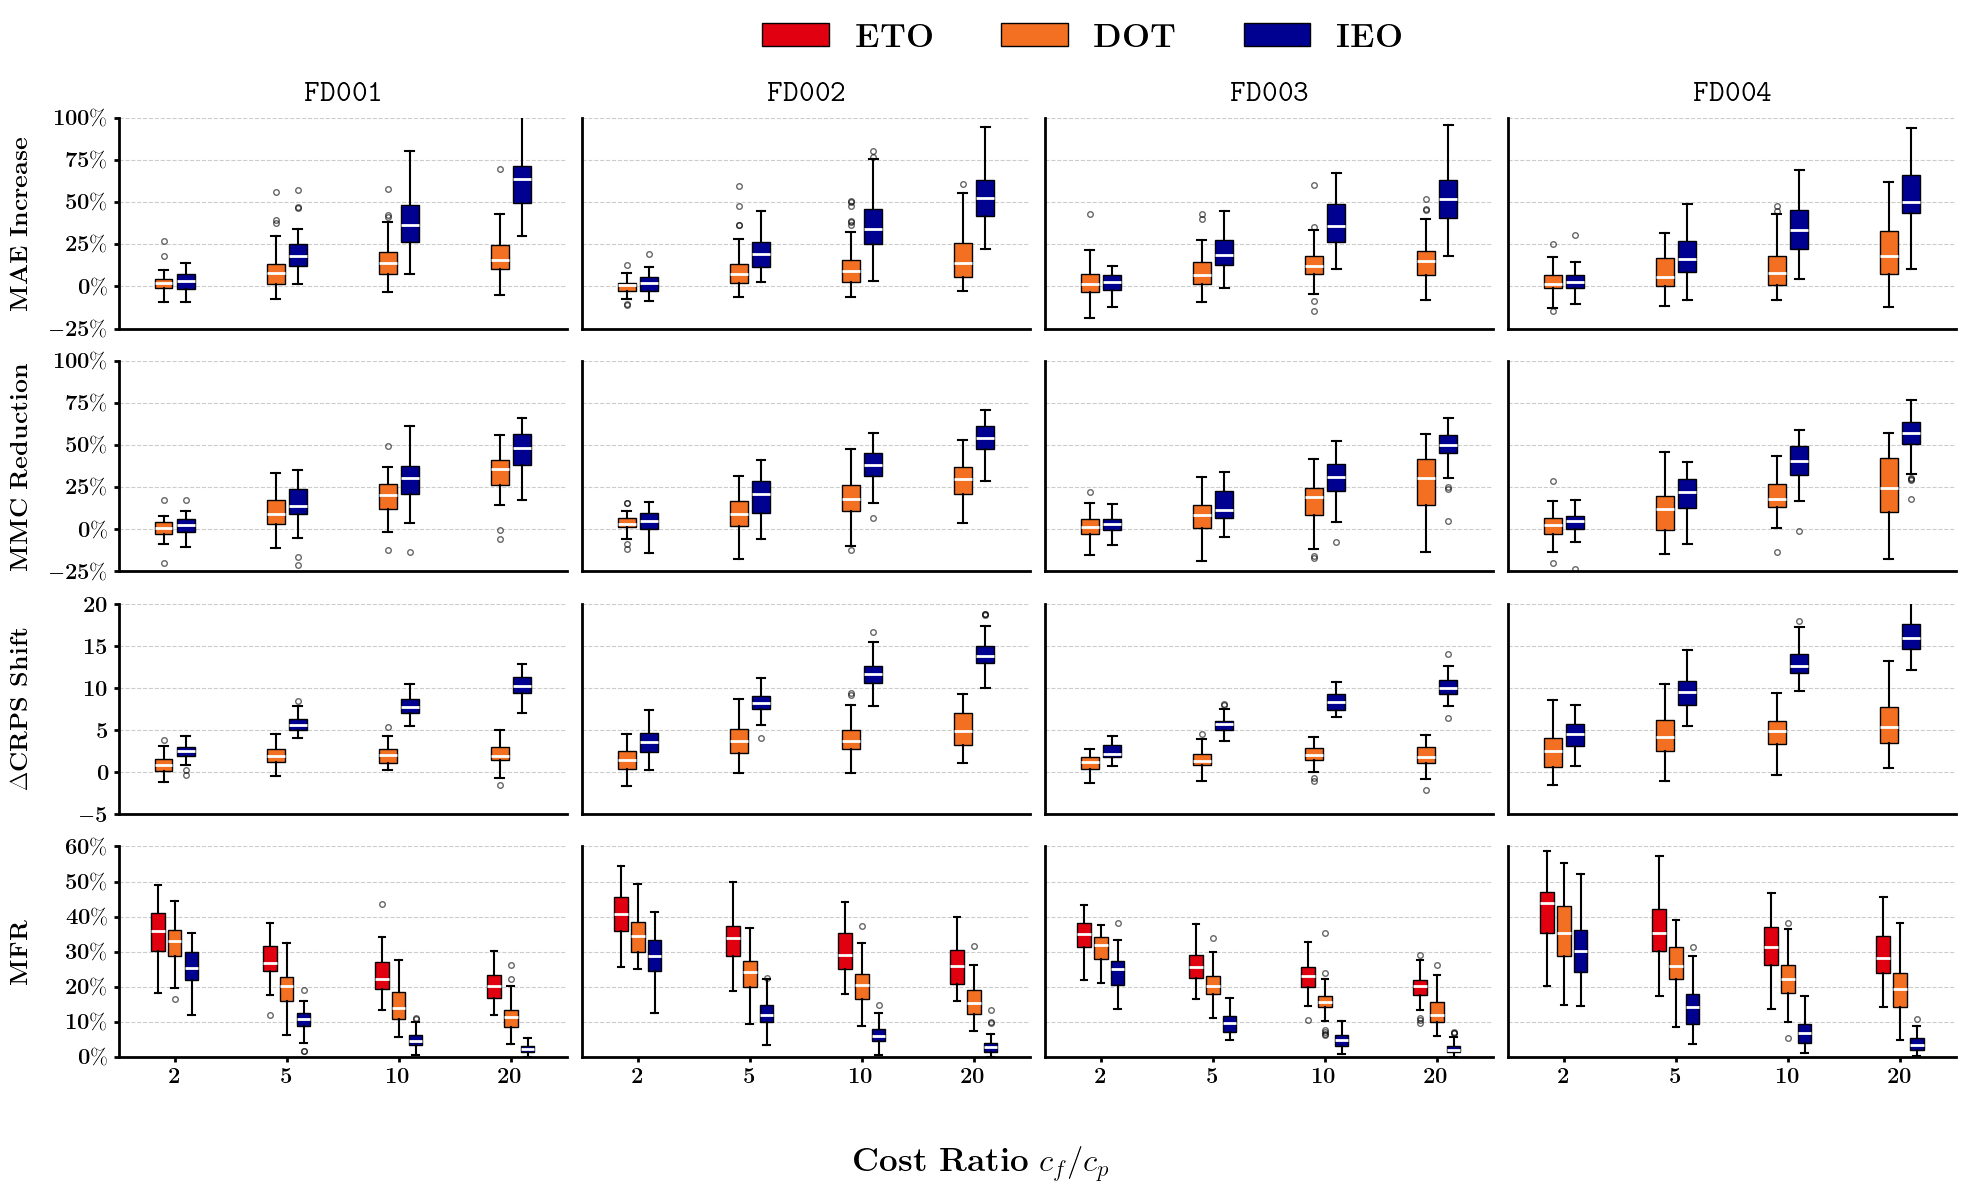

In [6]:
names = ["FD001", "FD002", "FD003", "FD004"]
ratios = [2, 5, 10, 20]

fig, axes = plt.subplots(
    4, 4,
    figsize=(20, 12),
    sharey="row",
)

ylims = [
    (-0.25, 1.0),
    (-0.25, 1.0),
    (-5, 20),
    (0.0, 0.6),
]

yticks = [
    [-0.25, 0, 0.25, 0.50, 0.75, 1.0],
    [-0.25, 0, 0.25, 0.50, 0.75, 1.0],
    [-5, 0, 5, 10, 15, 20],
    [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
]

ylabels = [
    r"\textbf{MAE Increase}",
    r"\textbf{MMC Reduction}",
    r"\textbf{$\Delta$CRPS Shift}",
    r"\textbf{MFR}",
]


def bold_percent(value, position):
    """Display fractional values as bold percentages."""
    return rf"$\mathbf{{{100 * value:.0f}\%}}$"


def bold_number(value, position):
    """Display numeric values using mathbf."""
    return rf"$\mathbf{{{value:g}}}$"


def draw_box(ax, values, position, color, width=0.16):
    """Draw one boxplot of split-level results."""
    values = values.detach().cpu().numpy()

    ax.boxplot(
        values,
        positions=[position],
        widths=width,
        manage_ticks=False,
        patch_artist=True,
        boxprops={
            "facecolor": color,
            "edgecolor": "k",
            "linewidth": 1,
        },
        medianprops={
            "color": "white",
            "linewidth": 2,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1.5,
        },
        capprops={
            "color": "black",
            "linewidth": 1.5,
        },
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "none",
            "markeredgecolor": "black",
            "alpha": 0.6,
        },
    )


# Draw all boxplots.
for col, name in enumerate(names):
    for position, ratio in enumerate(ratios):
        data = torch.load(
            f"../results/{name}_ratio={ratio:02d}.pth",
            map_location="cpu",
        )

        delta_eto = data[:, 0, 1] - data[:, 0, 2]

        # Rows 1–3: DOT and IEO compared with ETO.
        for method, offset, color in [
            (1, -0.1, c2),
            (2, +0.1, c3),
        ]:
            # Relative MAE increase.
            mae_increase = (
                (data[:, method, 0] - data[:, 0, 0])
                / data[:, 0, 0]
            )

            # Relative MMC reduction.
            mmc_reduction = (
                (data[:, 0, 3] - data[:, method, 3])
                / data[:, 0, 3]
            )

            # Absolute shift in delta CRPS.
            delta_method = (
                data[:, method, 1] - data[:, method, 2]
            )
            delta_shift = delta_method - delta_eto

            for row, values in enumerate([
                mae_increase,
                mmc_reduction,
                delta_shift,
            ]):
                draw_box(
                    axes[row, col],
                    values,
                    position + offset,
                    color,
                )

        # Row 4: absolute MFR for all three approaches.
        for method, offset, color in [
            (0, -0.15, c1),
            (1, 0.00, c2),
            (2, +0.15, c3),
        ]:
            draw_box(
                axes[3, col],
                data[:, method, 5],
                position + offset,
                color,
                width=0.12,
            )


# Apply formatting.
for row in range(4):
    for col in range(4):
        ax = axes[row, col]

        # Same y scale and tick positions within each row.
        ax.set_ylim(ylims[row])
        ax.set_yticks(yticks[row])

        # Percentage ticks on rows 1, 2, and 4.
        if row in (0, 1, 3):
            ax.yaxis.set_major_formatter(
                FuncFormatter(bold_percent)
            )
        else:
            ax.yaxis.set_major_formatter(
                FuncFormatter(bold_number)
            )

        # Explicit x positions and bold mathematical tick labels.
        ax.set_xlim(-0.5, 3.5)
        ax.set_xticks(range(len(ratios)))
        ax.set_xticklabels([
            rf"$\mathbf{{{ratio}}}$"
            for ratio in ratios
        ])

        # Only the first column displays y ticks and labels.
        # Tick locations remain available for every subplot's grid.
        ax.tick_params(
            axis="y",
            which="both",
            left=(col == 0),
            labelleft=(col == 0),
            right=False,
            labelright=False,
            labelsize=16,
            width=2,
        )

        # Only the last row displays x ticks and labels.
        ax.tick_params(
            axis="x",
            which="both",
            bottom=(row == 3),
            labelbottom=(row == 3),
            top=False,
            labeltop=False,
            labelsize=16,
            width=2,
        )

        # Horizontal grid behind the boxplots.
        ax.set_axisbelow(True)
        ax.grid(
            axis="y",
            which="major",
            color="gray",
            linewidth=0.8,
            alpha=0.4,
            linestyle='--'
        )
        ax.grid(
            axis="x",
            which="both",
            visible=False,
        )

        # Axes borders.
        for side in ("left", "bottom"):
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(2)

        for side in ("top", "right"):
            ax.spines[side].set_linewidth(0)
            ax.spines[side].set_visible(False)

        # Row labels appear only in the first column.
        if col == 0:
            ax.set_ylabel(
                ylabels[row],
                fontsize=18,
                labelpad=12,
            )

        # Use one shared xlabel instead of individual labels.
        ax.set_xlabel("")

        # LaTeX typewriter titles.
        if row == 0:
            ax.set_title(
                rf"\texttt{{{names[col]}}}",
                usetex=True,
                fontsize=22,
                pad=12,
            )


# Bold mathematical legend labels.
legend_handles = [
    Patch(
        facecolor=c1,
        edgecolor="black",
        label=r"$\mathbf{ETO}$",
    ),
    Patch(
        facecolor=c2,
        edgecolor="black",
        label=r"$\mathbf{DOT}$",
    ),
    Patch(
        facecolor=c3,
        edgecolor="black",
        label=r"$\mathbf{IEO}$",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.55, 1.04),
    ncol=3,
    frameon=False,
    fontsize=24,
)

# One large xlabel for the entire figure.
fig.supxlabel(
    r"\textbf{Cost Ratio} $c_f/c_p$",
    fontsize=24,
    y=0.05,
)

# Reserve space for the shared xlabel and legend.
fig.tight_layout(
    rect=(0, 0.055, 1, 0.99),
    w_pad=0.6,
    h_pad=0.5,
)
fig.align_ylabels(axes[:, 0])
fig.savefig("./figs/case2.pdf", bbox_inches="tight")


In [7]:
name = ["FD001", "FD002", "FD003", "FD004"]
ratio = [2, 5, 10, 20]
for i in range(4):
    ETO = 0
    DOT = 0
    IEO = 0
    for j in range(4):
        data = torch.load("../results/%s_ratio=%02d.pth" % (name[i], ratio[j]))
        
        ETO += data[:,0,-1].mean()
        DOT += data[: 1,-1].mean()
        IEO += data[:,0,-1].mean() + data[:,2,-1].mean()
        
    print("\\texttt{%s} & %.0f &%.0f &%.0f \\\\" % (name[i], ETO/4, DOT/4, IEO/4))

\texttt{FD001} & 69 &26 &159 \\
\texttt{FD002} & 81 &31 &173 \\
\texttt{FD003} & 73 &26 &162 \\
\texttt{FD004} & 63 &31 &154 \\


In [8]:
import torch
import numpy as np


names = ["FD001", "FD002", "FD003", "FD004"]
ratios = [2, 5, 10, 20]


def mean_std(x, scale=1.0, decimals=1):
    """Return LaTeX string: $mean \pm std$."""
    x = x.detach().cpu().numpy() * scale

    mean = np.mean(x)
    std = np.std(x, ddof=1)

    return rf"${mean:.{decimals}f} \pm {std:.{decimals}f}$"


# ============================================================
# Table header
# ============================================================

print(r"""
\begin{table*}[t]
\centering
\caption{
Results on the four C-MAPSS subsets under different cost ratios.
Entries report mean $\pm$ standard deviation across trials.
MAE Increase, MMC Reduction, and MFR are reported in percentage points.
}
\label{tab:case2_results}
\resizebox{\textwidth}{!}{
\begin{tabular}{cc cc cc cc ccc}
\toprule
& &
\multicolumn{2}{c}{\textbf{MAE Increase (\%)}} &
\multicolumn{2}{c}{\textbf{MMC Reduction (\%)}} &
\multicolumn{2}{c}{\textbf{$\Delta$CRPS Shift}} &
\multicolumn{3}{c}{\textbf{MFR (\%)}} \\
\cmidrule(lr){3-4}
\cmidrule(lr){5-6}
\cmidrule(lr){7-8}
\cmidrule(lr){9-11}
\textbf{Subset} &
$\boldsymbol{c_f/c_p}$ &
\textbf{DOT} &
\textbf{IEO} &
\textbf{DOT} &
\textbf{IEO} &
\textbf{DOT} &
\textbf{IEO} &
\textbf{ETO} &
\textbf{DOT} &
\textbf{IEO} \\
\midrule
""".strip())


# ============================================================
# Table body
# ============================================================

for name_idx, name in enumerate(names):

    for ratio_idx, ratio in enumerate(ratios):

        data = torch.load(
            f"../results/{name}_ratio={ratio:02d}.pth",
            map_location="cpu",
        )

        delta_eto = data[:, 0, 1] - data[:, 0, 2]

        results = {}

        # DOT and IEO relative metrics
        for method, method_name in [
            (1, "DOT"),
            (2, "IEO"),
        ]:

            # Relative MAE increase
            mae_increase = (
                (data[:, method, 0] - data[:, 0, 0])
                / data[:, 0, 0]
            )

            # Relative MMC reduction
            mmc_reduction = (
                (data[:, 0, 3] - data[:, method, 3])
                / data[:, 0, 3]
            )

            # Shifted Delta CRPS
            delta_method = (
                data[:, method, 1] - data[:, method, 2]
            )
            delta_shift = delta_method - delta_eto

            results[f"mae_{method_name}"] = mean_std(
                mae_increase,
                scale=100,
                decimals=1,
            )

            results[f"mmc_{method_name}"] = mean_std(
                mmc_reduction,
                scale=100,
                decimals=1,
            )

            results[f"crps_{method_name}"] = mean_std(
                delta_shift,
                scale=1,
                decimals=1,
            )

        # Absolute MFR
        results["mfr_ETO"] = mean_std(
            data[:, 0, 5],
            scale=100,
            decimals=1,
        )

        results["mfr_DOT"] = mean_std(
            data[:, 1, 5],
            scale=100,
            decimals=1,
        )

        results["mfr_IEO"] = mean_std(
            data[:, 2, 5],
            scale=100,
            decimals=1,
        )

        # Dataset name appears once over four ratios
        if ratio_idx == 0:
            subset = rf"\multirow{{4}}{{*}}{{\texttt{{{name}}}}}"
        else:
            subset = ""

        print(
            f"{subset} & "
            f"{ratio} & "
            f"{results['mae_DOT']} & "
            f"{results['mae_IEO']} & "
            f"{results['mmc_DOT']} & "
            f"{results['mmc_IEO']} & "
            f"{results['crps_DOT']} & "
            f"{results['crps_IEO']} & "
            f"{results['mfr_ETO']} & "
            f"{results['mfr_DOT']} & "
            f"{results['mfr_IEO']} "
            r"\\"
        )

    if name_idx < len(names) - 1:
        print(r"\midrule")


# ============================================================
# Table footer
# ============================================================

print(r"""
\bottomrule
\end{tabular}
}
\end{table*}
""".strip())

\begin{table*}[t]
\centering
\caption{
Results on the four C-MAPSS subsets under different cost ratios.
Entries report mean $\pm$ standard deviation across trials.
MAE Increase, MMC Reduction, and MFR are reported in percentage points.
}
\label{tab:case2_results}
\resizebox{\textwidth}{!}{
\begin{tabular}{cc cc cc cc ccc}
\toprule
& &
\multicolumn{2}{c}{\textbf{MAE Increase (\%)}} &
\multicolumn{2}{c}{\textbf{MMC Reduction (\%)}} &
\multicolumn{2}{c}{\textbf{$\Delta$CRPS Shift}} &
\multicolumn{3}{c}{\textbf{MFR (\%)}} \\
\cmidrule(lr){3-4}
\cmidrule(lr){5-6}
\cmidrule(lr){7-8}
\cmidrule(lr){9-11}
\textbf{Subset} &
$\boldsymbol{c_f/c_p}$ &
\textbf{DOT} &
\textbf{IEO} &
\textbf{DOT} &
\textbf{IEO} &
\textbf{DOT} &
\textbf{IEO} &
\textbf{ETO} &
\textbf{DOT} &
\textbf{IEO} \\
\midrule
\multirow{4}{*}{\texttt{FD001}} & 2 & $2.6 \pm 6.0$ & $3.1 \pm 5.4$ & $0.7 \pm 5.7$ & $2.1 \pm 5.6$ & $0.9 \pm 1.0$ & $2.4 \pm 0.8$ & $35.7 \pm 6.6$ & $32.3 \pm 6.0$ & $25.8 \pm 5.7$ \\
 & 5 & $9.9 \pm 12.2$ 

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\xie\AppData\Local\Temp\ipykernel_28500\1456443054.py:10: SyntaxWarning: invalid escape sequence '\p'
  """Return LaTeX string: $mean \pm std$."""
